In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
# loading the dataset
data = load_breast_cancer()

#creating dataframe pandas
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
# separate Features and Target
X = df.drop(
    "target",
    axis=1
)

y = df["target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


In [8]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [9]:
scaler = StandardScaler()

In [10]:
X_train_scaled = scaler.fit_transform(
    X_train
)

In [11]:
X_test_scaled = scaler.transform(
    X_test
)

In [12]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)


In [13]:
# train the KNN model
knn_model.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [16]:
# making prediction and displaying it
y_pred_knn = knn_model.predict(
    X_test_scaled
)
print("Predictions:")
print(y_pred_knn[:20])
print("Actual Values:")
print(y_test.values[:20])

Predictions:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]
Actual Values:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


In [17]:
# calculate Accuracy
accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print(
    "KNN Accuracy:",
    accuracy_knn
)

KNN Accuracy: 0.956140350877193


In [18]:
# report classification
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)


              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Confusion Matrix:
[[39  3]
 [ 2 70]]


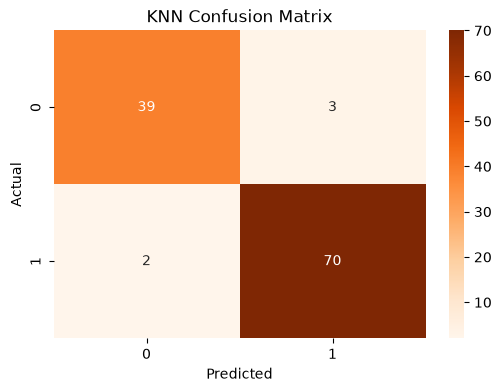

In [20]:
# confusion Matrix
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print("Confusion Matrix:")
print(cm_knn)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "KNN Confusion Matrix"
)

plt.show()

In [21]:
# testing different K values
k_values = range(1, 21)

k_accuracy = []


In [22]:
# training different KNN model for each k values
for k in k_values:
    
    model = KNeighborsClassifier(
        n_neighbors=k
    )
    
    model.fit(
        X_train_scaled,
        y_train
    )
    
    predictions = model.predict(
        X_test_scaled
    )
    
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    
    k_accuracy.append(
        accuracy
    )

In [23]:
for k, accuracy in zip(
    k_values,
    k_accuracy
):
    
    print(
        "K =", k,
        "Accuracy =", round(accuracy, 4)
    )

K = 1 Accuracy = 0.9386
K = 2 Accuracy = 0.9298
K = 3 Accuracy = 0.9825
K = 4 Accuracy = 0.9474
K = 5 Accuracy = 0.9561
K = 6 Accuracy = 0.9561
K = 7 Accuracy = 0.9737
K = 8 Accuracy = 0.9737
K = 9 Accuracy = 0.9737
K = 10 Accuracy = 0.9649
K = 11 Accuracy = 0.9737
K = 12 Accuracy = 0.9737
K = 13 Accuracy = 0.9737
K = 14 Accuracy = 0.9649
K = 15 Accuracy = 0.9737
K = 16 Accuracy = 0.9737
K = 17 Accuracy = 0.9825
K = 18 Accuracy = 0.9825
K = 19 Accuracy = 0.9737
K = 20 Accuracy = 0.9737


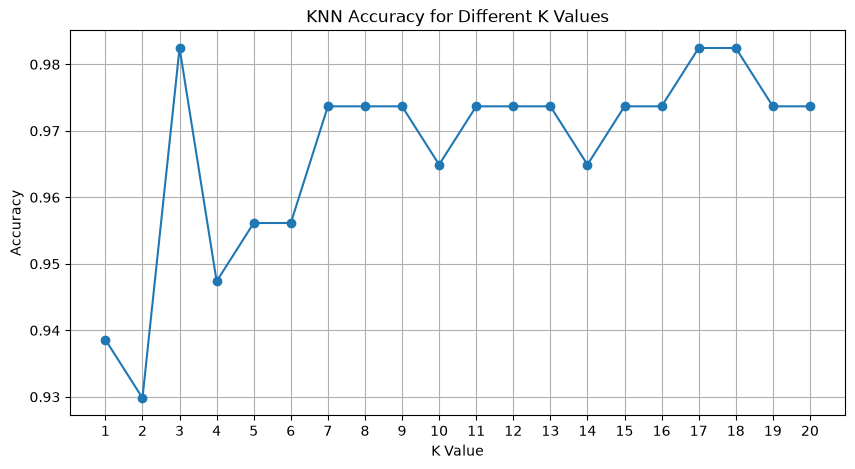

In [24]:
# plot K vs accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    k_values,
    k_accuracy,
    marker="o"
)

plt.xlabel(
    "K Value"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "KNN Accuracy for Different K Values"
)

plt.xticks(
    list(k_values)
)

plt.grid(
    True
)

plt.show()

In [25]:
# find the best K values
best_k = k_values[
    np.argmax(k_accuracy)
]

best_accuracy = max(
    k_accuracy
)

print(
    "Best K:",
    best_k
)

print(
    "Best Accuracy:",
    best_accuracy
)

Best K: 3
Best Accuracy: 0.9824561403508771


In [28]:
# training the KNN model using the best k
best_knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)
best_knn_model.fit(
    X_train_scaled,
    y_train
)
best_knn_predictions = best_knn_model.predict(
    X_test_scaled
)

In [30]:
#Evaluate the Final KNN model
best_knn_accuracy = accuracy_score(
    y_test,
    best_knn_predictions
)

print(
    "Final KNN Accuracy:",
    round(best_knn_accuracy * 100, 2),
    "%"
)
print(
    classification_report(
        y_test,
        best_knn_predictions
    )
)


Final KNN Accuracy: 98.25 %
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        42
           1       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



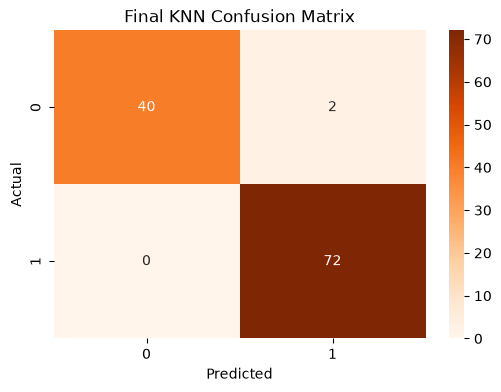

In [31]:
# Final Confusion Matrix
best_knn_cm = confusion_matrix(
    y_test,
    best_knn_predictions
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    best_knn_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Final KNN Confusion Matrix"
)

plt.show()

In [ ]:
#final report
print(
    "KNN Model Performance"
)

print(
    "---------------------"
)

print(
    "Best K:",
    best_k
)

print(
    "Accuracy:",
    round(
        best_knn_accuracy,
        4
    )
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        best_knn_predictions
    )
)

print(
    "\nConfusion Matrix:"
)

print(
    best_knn_cm
)

KNN Model Performance
---------------------
Best K: 3
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        42
           1       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
[[40  2]
 [ 0 72]]
